# **Data Preparation:**

In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, precision_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
# Load Dataset
df = pd.read_csv("heart_disease_uci.csv")

# Check first 5 rows
df.head()

# Check for missing values and data types
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [44]:
# Handling missing values
for col in df.select_dtypes(include=["float64", "int64"]).columns:
  df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in df.select_dtypes(include=["object"]).columns:
 df[col] = df[col].fillna(df[col].mode()[0])

# Encoding categorical Variables
df =pd.get_dummies(df, drop_first=True)

# Scaling the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop("num", axis=1))

# Recreating the dataframe
X = pd.DataFrame(scaled_features, columns=df.columns[:-1])
y = df["num"]

# Converting values into 0 and 1
y_binary = y.apply(lambda x: 1 if x > 0 else 0)

# checking shapes and value counts
print("X shape:", X.shape)
print("y shape:", y.shape)

y_binary.value_counts()

X shape: (920, 22)
y shape: (920,)


/tmp/ipython-input-3731464862.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


,count
num,
1,509
0,411


# **Model Training**




In [45]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Train logisitic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Making predicitions
y_pred = log_reg.predict(X_test)


# **Model Evalution**

In [46]:
# Evaluating performance
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision Score:", round(precision_score(y_test, y_pred), 3))
print("Recall Score:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.853
Precision Score: 0.88
Recall Score: 0.872
F1 Score: 0.876

Confusion Matrix:
 [[62 13]
 [14 95]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82        75
           1       0.88      0.87      0.88       109

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



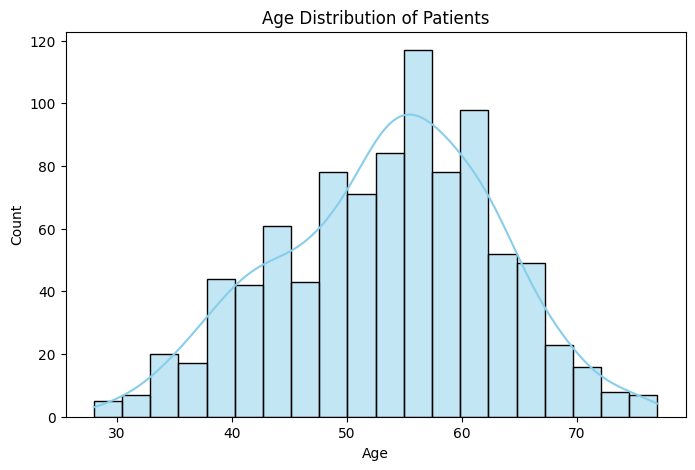

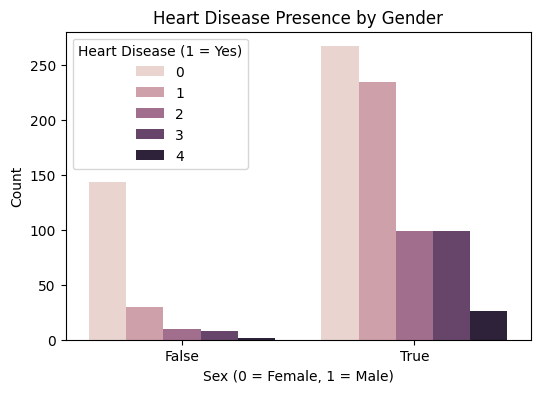

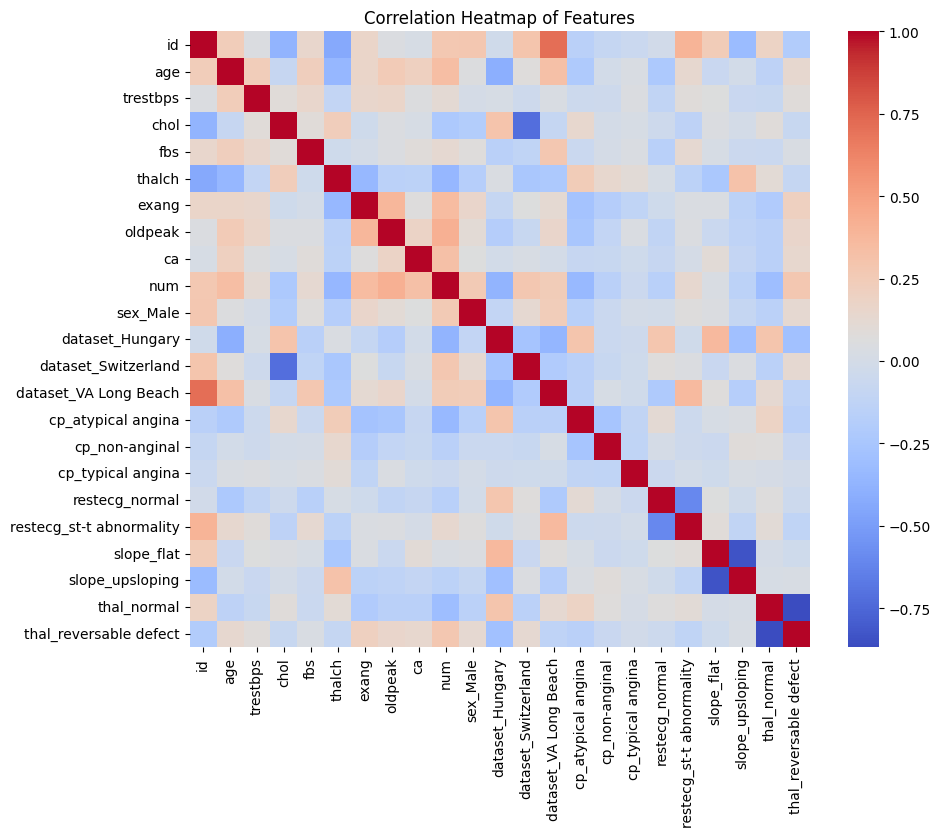

In [54]:
# Visiualisation

# Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Heart Disease by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex_Male', hue='num')
plt.title("Heart Disease Presence by Gender")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.legend(title="Heart Disease (1 = Yes)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()